
# Data Augmentation for Pneumonia Detection in X-Ray Images

This notebook demonstrates how to apply data augmentation to the
[Chest X-Ray Pneumonia Dataset](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia).

The images in this database are grayscale x-ray images; some example images are pictured below.

<img src='images/pneunomia.png' width=25% />

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

We load in the training, validation and test data, then create DataLoaders for each of these sets of data.

We perform some simple [data augmentation](https://medium.com/nanonets/how-to-use-deep-learning-when-you-have-limited-data-part-2-data-augmentation-c26971dc8ced) by randomly flipping and rotating the given image data. We do this by defining a torchvision `transform`, and you can learn about all the transforms that are used to pre-process and augment data, [here](https://pytorch.org/vision/0.9/transforms.html).

This type of data augmentation should add some positional variety to these images, so that when we train a model on this data, it will be robust in the face of geometric changes (i.e. it will recognize a ship, no matter which direction it is facing). It's recommended that you choose one or two transforms.

In [ ]:

# Data transforms and loaders
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Convert images to grayscale
    transforms.Resize((128, 128)), # Resize images to 128x128
    transforms.RandomHorizontalFlip(), # Randomly flip images horizontally
    transforms.RandomRotation(10), # Rotate images by ±10 degrees
    transforms.ToTensor(), # Convert images to tensor -> [0, 1] range
    transforms.Normalize((0.5,), (0.5,)) # Center images: Scale from [0, 1] to [-1, 1]
])

# Data transforms for validation and testing (no augmentation!)
test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Note: same normalization as training
])

train_data = datasets.ImageFolder('data/chest_xray/train', transform=train_transforms)
val_data   = datasets.ImageFolder('data/chest_xray/val', transform=test_transforms)
test_data  = datasets.ImageFolder('data/chest_xray/test', transform=test_transforms)

batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

classes = train_data.classes
print("Classes:", classes)


Classes: ['NORMAL', 'PNEUMONIA']


### Visualize a Batch of Training Data

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

# helper function to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    img = np.squeeze(img) # remove single-dimensional entries from the shape
    plt.imshow(img, cmap='gray')  # convert from Tensor image

(1, 128, 128)


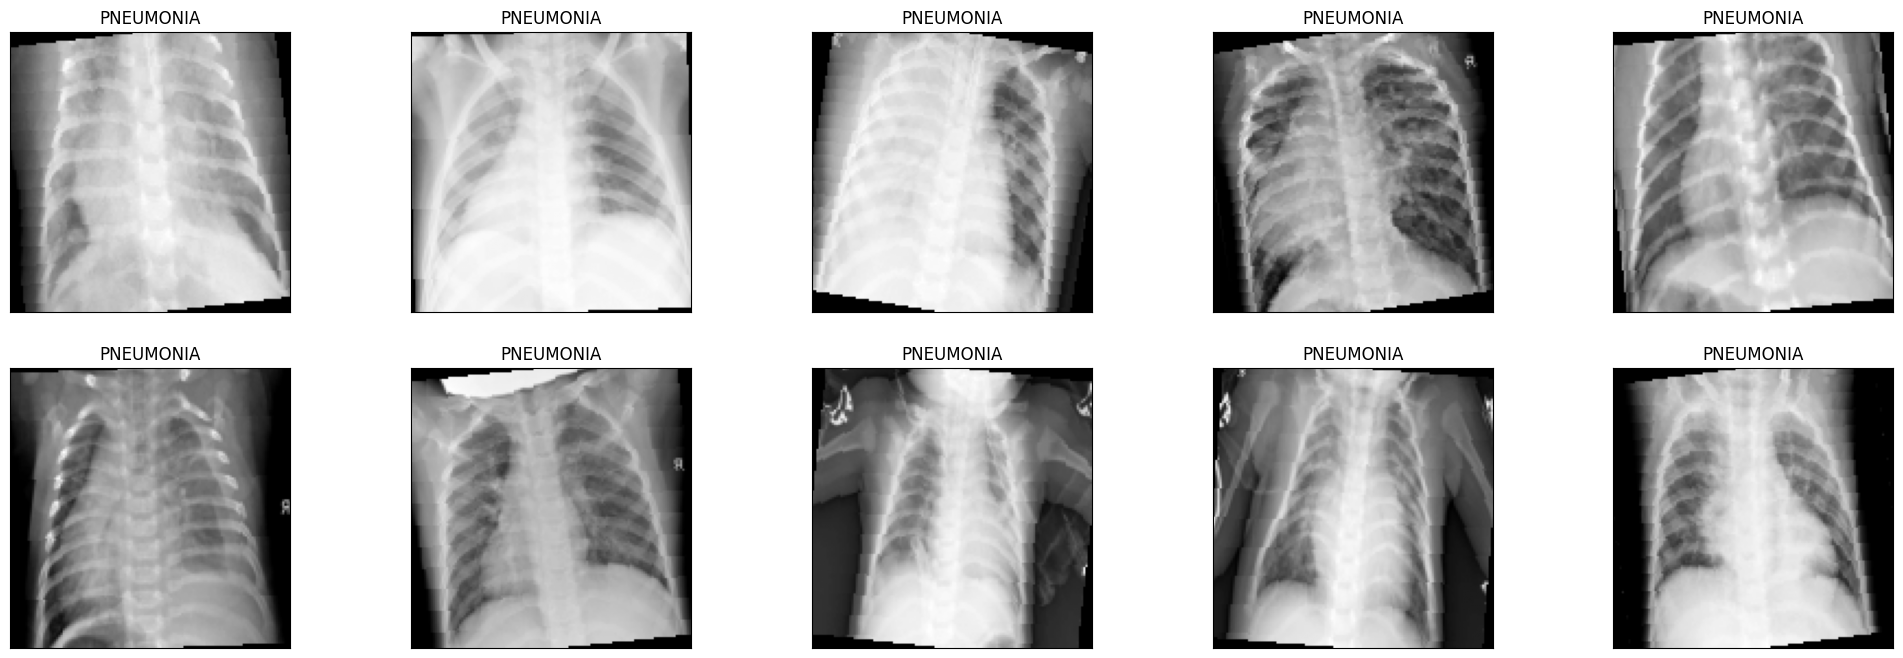

In [4]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = dataiter.__next__()
images = images.numpy() # convert images to numpy for display

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 8))
# display 10 images
for idx in np.arange(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

    # take a look at the shape of one image
    if idx == 0:
        print(images[idx].shape) # grayscale image: 1x128x128